# Exploring the Trump tariffs

#### <span style="color:red"> Scrape data on the tariff rates online from news articles???? </span>

In [22]:
# Importing libraries
import requests
from bs4 import BeautifulSoup

In [24]:
# Step 1: Send a GET request to the website
URL = 'https://www.newsweek.com/trump-reciprocal-tariff-chart-2054514'

response = requests.get(URL)

# Checking the status code of the response
print(f"Status Code: {response.status_code}")

# If the response is successful, proceed with parsing
if response.status_code == 200:
    print(f"Successfully accessed the webpage {URL}")
else:
    print(f"Failed to access the webpage: {URL}")

Status Code: 403
Failed to access the webpage: https://www.newsweek.com/trump-reciprocal-tariff-chart-2054514


## <span style="color:red"> Didn't work.... so instead, download data and import </span>

In [27]:
import pandas as pd

# Specify the path to your Excel file
file_path = "/Users/andrealorensy/Desktop/Andrea's Files/CEMFI/Summer School and Short Courses/Data Science/Codes/Trump tariffs.xlsx"

# Read the Excel file into a DataFrame
tariff_data = pd.read_excel(file_path)

# Display the first few rows of the DataFrame
#print(tariff_data.head())

# Display the DataFrame
tariff_data

,Country,Tariffs Charged to the U.S.A. (%),U.S.A. Discounted Reciprocal Tariffs (%)
0,China,67,34
1,European Union,39,20
2,Vietnam,90,46
3,Taiwan,64,32
4,Japan,46,24
...,...,...,...
180,Tokelau,10,10
181,Guinea-Bissau,10,10
182,Svalbard and Jan Mayen,10,10
183,Heard and McDonald Islands,10,10


## <span style="color:red"> Make an interactive table using Reactable</span>

In [30]:
# Install Reactable if not yet installed
#!pip install reactable

# Import Reactable and features
from reactable import Reactable, embed_css, Column

In [32]:
# Note that currently this function is required to put css into notebooks.
embed_css()

# Create and display the interactive table
#Reactable(tariff_data)

In [34]:
# Search option
Reactable(
    tariff_data,
    columns=[
        Column(id='Country"', filterable=True),  # Enable filtering for 'Country' column
        Column(id='Tariffs Charged to the U.S.A. (%)', filterable=True),        # To disable filtering for 'tariff' column, set to False
        Column(id='U.S.A. Discounted Reciprocal Tariffs (%)', filterable=True),  # To disable filtering for 'tariff' column, set to False
    ],
    default_page_size=15,
    searchable=True,
    filterable=True,
)


ReactableWidget(props={'data': {'Country': ['China', 'European Union', 'Vietnam', 'Taiwan', 'Japan', 'India', …

## <span style="color:red"> Some simple data analysis </span>

In [37]:
# Count total number of countries slapped with tariffs
N_total = len(tariff_data)

# Share of countries with the 10% tariff rate
N_10pct = (tariff_data['U.S.A. Discounted Reciprocal Tariffs (%)'] == 10).sum()
share_10pct = N_10pct/N_total * 100
print("Share of countries with 10% tariff:", round(share_10pct,2), "% \n")

## Share of countries with different ranges of tariffs
# Define the ranges as tuples (lower_bound, upper_bound)
ranges = [(0, 10), (10, 20), (20, 30), (30, 40), (40, 50)]

# Initialize a dictionary to store the counts (recall that a dictionary is different from a dataframe!)
range_counts = {}
range_shares = {}

# Iterate over each range and count the rows
for lower, upper in ranges:
    count = ((tariff_data['U.S.A. Discounted Reciprocal Tariffs (%)'] > lower) & 
             (tariff_data['U.S.A. Discounted Reciprocal Tariffs (%)'] <= upper)).sum()
    share = round(count/N_total * 100,2)
    if upper == 10:
        range_counts[f'{upper}%'] = count
        range_shares[f'{upper}%'] = share
    else:
        range_counts[f'{lower}-{upper}%'] = count
        range_shares[f'{lower}-{upper}%'] = share
        
# Display the shares
for range_str, shares in range_shares.items():
    if range_str == '10%':
        print(f'Share of countries with tariffs = {range_str}: {shares}%')
    else:
        print(f'Share of countries with tariffs between {range_str}: {shares}%')

Share of countries with 10% tariff: 67.57 % 

Share of countries with tariffs = 10%: 67.57%
Share of countries with tariffs between 10-20%: 8.65%
Share of countries with tariffs between 20-30%: 8.11%
Share of countries with tariffs between 30-40%: 10.27%
Share of countries with tariffs between 40-50%: 5.41%


In [39]:
# Get countries with tariffs between 30-40%
filtered_data = tariff_data[(tariff_data['U.S.A. Discounted Reciprocal Tariffs (%)'] > 30) & 
                  (tariff_data['U.S.A. Discounted Reciprocal Tariffs (%)'] <= 40)]

# Select only the first and third columns (index positions 0 and 2)
result = filtered_data.iloc[:, [0, 2]]

# Display the result
print("List of countries with tariffs between 30-40%: \n", result)

List of countries with tariffs between 30-40%: 
                     Country  U.S.A. Discounted Reciprocal Tariffs (%)
0                     China                                        34
3                    Taiwan                                        32
7                  Thailand                                        36
8               Switzerland                                        31
9                 Indonesia                                        32
15               Bangladesh                                        37
41                   Serbia                                        37
47                 Botswana                                        37
93                    Libya                                        31
108               Mauritius                                        40
109                    Fiji                                        32
112           Liechtenstein                                        37
113                  Guyana              

## <span style="color:red"> Visualizing the Trump tariffs </span>

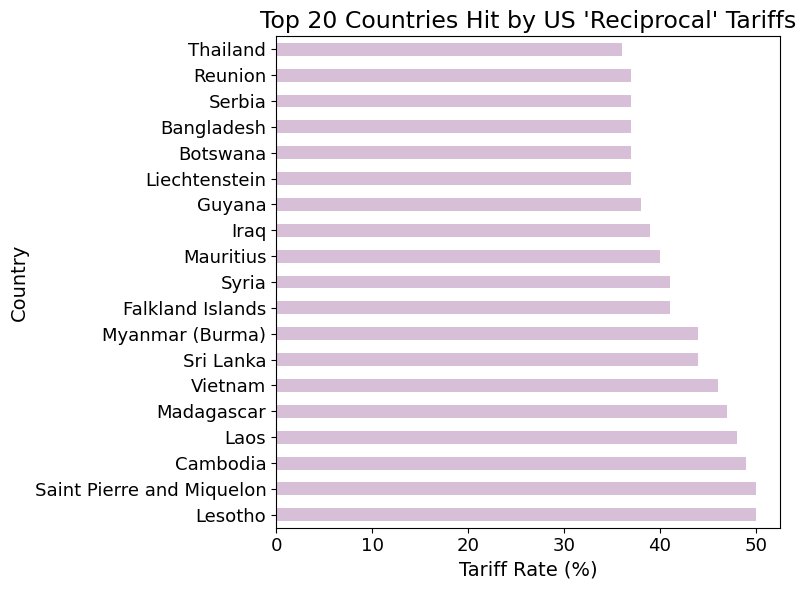

In [42]:
# Importing the necessary library
import matplotlib.pyplot as plt
import pandas as pd

# Sort data in descending order of discounted reciprocal tariffs
tariff_data_sorted = tariff_data.sort_values(by='U.S.A. Discounted Reciprocal Tariffs (%)', ascending=False)

# Select top20 countries for horizontal bar plot (get rows 1-20, and columns 1 & 3)
top20_df = tariff_data_sorted.iloc[0:19,[0,2]]

# Plot
top20_df.plot.barh(x='Country', y='U.S.A. Discounted Reciprocal Tariffs (%)', color='thistle', figsize=(8, 6), legend=False)
plt.title("Top 20 Countries Hit by US 'Reciprocal' Tariffs", fontsize=17)
plt.ylabel('Country', fontsize=14)
plt.xlabel('Tariff Rate (%)', fontsize=14)
plt.tick_params(labelsize=13)
plt.tight_layout()
plt.show()


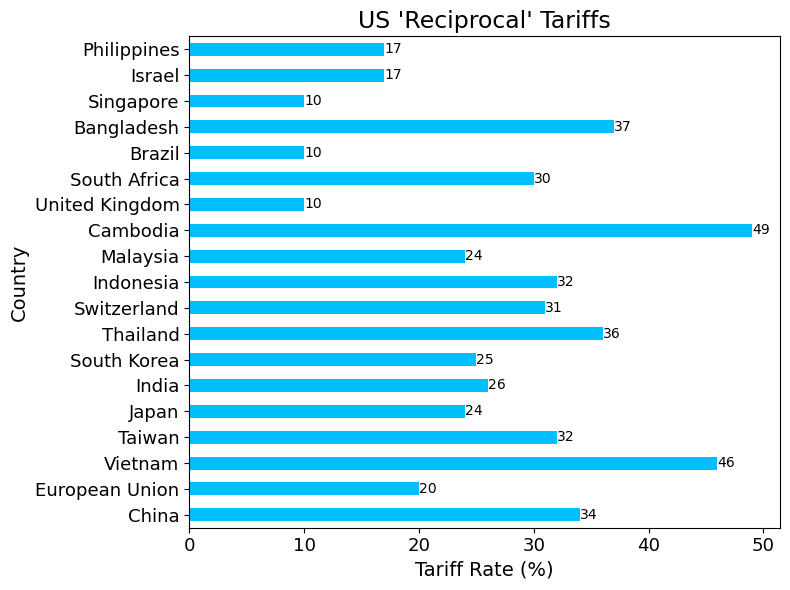

In [44]:
# Select 20 highlight countries for horizontal bar plot (get rows 1-20, and columns 1 & 3)
top20_df2 = tariff_data.iloc[0:19,[0,2]]

## Plot
ax = top20_df2.plot.barh(x='Country', y='U.S.A. Discounted Reciprocal Tariffs (%)', color='deepskyblue', figsize=(8, 6), legend=False)

# The ax.containers attribute holds the bar containers. Iterating over these containers allows you to add labels to each bar
for container in ax.containers:
    ax.bar_label(container, label_type='edge', fontsize=10)

plt.title("US 'Reciprocal' Tariffs", fontsize=17)
plt.ylabel('Country', fontsize=14)
plt.xlabel('Tariff Rate (%)', fontsize=14)
plt.tick_params(labelsize=13)
plt.tight_layout()
plt.show()


## <span style="color:red"> Now let's try to scrape some images online, from news articles on the Trump tariffs </span>

In [53]:
# Importing libraries
import requests
from bs4 import BeautifulSoup
from IPython.display import Image, display # this is needed for the display of the image loaded directly from scraped page

# Step 1: Send a GET request to the website
URL = 'https://www.theguardian.com/us-news/2025/apr/03/donald-trump-tariffs-antarctica-uninhabited-heard-mcdonald-islands'

response = requests.get(URL)

# Checking the status code of the response
print(f"Status Code: {response.status_code}")

# If the response is successful, proceed with parsing
if response.status_code == 200:
    print(f"Successfully accessed the webpage {URL}")
else:
    print(f"Failed to access the webpage: {URL}")

Status Code: 200
Successfully accessed the webpage https://www.theguardian.com/us-news/2025/apr/03/donald-trump-tariffs-antarctica-uninhabited-heard-mcdonald-islands


In [55]:
# Step 2: Parse the HTML content using BeautifulSoup
soup = BeautifulSoup(response.content, 'html.parser')

## Get the title
title_tag = soup.find('title')

title_tag

if title_tag:
    title = title_tag.get_text()
    # Clean the title by removing unwanted text
    # For example, removing ' | The Guardian'
    cleaned_title = title.replace(' | Trump tariffs | The Guardian', '').strip()
    print('Title:', cleaned_title)
else:
    print('No title tag found.')

Title: ‘Nowhere on Earth is safe’: Trump imposes tariffs on uninhabited islands near Antarctica


In [57]:
## Locate image by locating the <meta> tag with property='og:image'
meta_tag = soup.find('meta', property='og:image')

# Display
meta_tag

# Check if the meta tag exists and contains a 'content' attribute
if meta_tag and 'content' in meta_tag.attrs:
    image_url = meta_tag['content']
    print('Image URL:', image_url)
else:
    print('No og:image meta tag found.')
    

Image URL: https://i.guim.co.uk/img/media/1c1addd9f7a5f841fe692cab3154bc4d1acdb35a/0_66_1988_1193/master/1988.jpg?width=1200&height=630&quality=85&auto=format&fit=crop&overlay-align=bottom%2Cleft&overlay-width=100p&overlay-base64=L2ltZy9zdGF0aWMvb3ZlcmxheXMvdGctZGVmYXVsdC5wbmc&enable=upscale&s=da364cf68b3fd8d7813b856706ec9f29


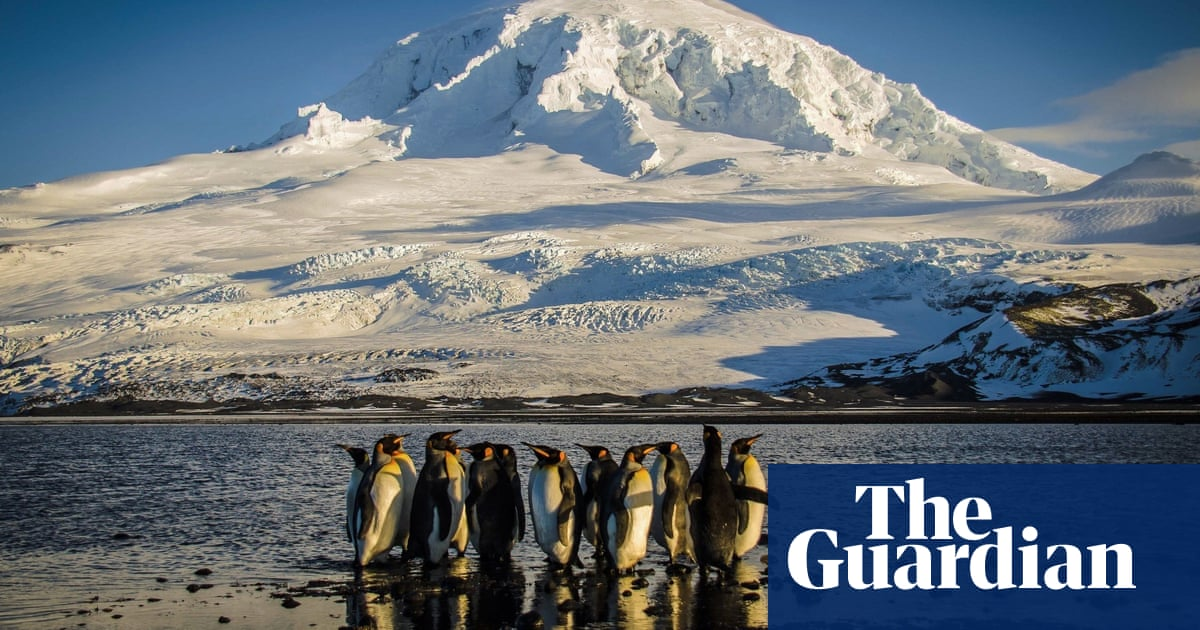

In [59]:
# Fetch the image
img_response = requests.get(image_url)

# Display the image using raw content
display(Image(img_response.content))